### data collection and processing
To aquire the necessary song lyric data, [Genius' API](https://docs.genius.com) is used, because it could provide access to all lyrics from the initial selection. The process of obtaining lyrics is fairly easy, because there is only a client access token needed, which can be aquired with a free user account. The access token is locally stored in a [file](./key.json). To send queries to the API, the [lyricsgenius](https://pypi.org/project/lyricsgenius/) module is used, it returns the lyrics for a provided artist and songtitle as a string, which is then processed and stored together with other information for each song in a separate [file](./songlist_with_lyrics.json) *(only visible after initial execution of the notebook)*.

One remark on the 250 songs from 1976 - 2025 has to be done: It is mostly the same scope as [The Billboard Melodic Music Dataset](https://github.com/madelinehamilton/BiMMuDa), exept for some years from 2020 and onwards. I personally skipped songs that are present in the top five charts within two years. Otherwise some songs would have occured twice in the list, which is not the intention of this project, as I want to analyse 250 *different* songs.

In [193]:
import re
import json
import string
import numpy as np
import lyricsgenius
import pandas as pd
import matplotlib.pyplot as plt
from retry import retry

In [68]:
# open the json-file containing all songs categorized by year and keyed with artist and title
with open('songs.json', 'r') as file:
    data = json.load(file)

In [69]:
# write an empty json file for all songs to be analized
with open('songlist_with_lyrics.json', 'w') as f:
    json.dump({'songs':[]}, f, indent=4)

In [70]:
# read the API-key
with open('key.json', 'r') as file:
    genius_api = lyricsgenius.Genius(json.load(file)['apikey'])

In [71]:
# API call, queried by artist and title of each song
@retry(delay=5)
def fetch_from_api(artist, title):
    try:
        lyrics = genius_api.search_song(artist, title).lyrics
    except:
        print(f'ERROR: Timed out while fetching {title} by {artist} - trying it again...')
        raise
    return lyrics

In [ ]:
# strip linebreaks '\n', punctuation and unwanted words (especially part names of songs) from song text provided by the API
def process_lyrics(lyrics):
    processed_lyrics = lyrics.lower()
    processed_lyrics = re.sub('\\[(.*?)\\]', '', processed_lyrics)

    translation_table_punct = str.maketrans('', '', string.punctuation)
    translation_table_linebreaks = str.maketrans('\n', ' ')
    processed_lyrics = processed_lyrics.translate(translation_table_punct).translate(translation_table_linebreaks)

    processed_lyrics = processed_lyrics.lstrip()
    processed_lyrics = processed_lyrics.replace('   ', ' ')
    processed_lyrics = processed_lyrics.replace('  ', ' ')
    return processed_lyrics

In [73]:
# function to append the json-string containing the lyrics to the already existing entries
def write_to_file(per_song_data):
    with open('songlist_with_lyrics.json', 'r') as f:
        file_data = json.load(f)
        file_data['songs'].append(per_song_data)

    with open('songlist_with_lyrics.json', 'w') as f:
        json.dump(file_data, f, indent=4)

In [74]:
# looping through the songs per year
for year in data:
    for song in range(len(data[year])):
        artist = data[year][song]['artist']
        title = data[year][song]['title']

        # append year to song's existing data
        year_dict = {'year': f"{year}"}
        data_per_song = data[year][song]
        data_per_song.update(year_dict)

        lyrics = fetch_from_api(artist, title)    
        
        # clean up the data from the API and update the content of the json-string
        lyrics = process_lyrics(lyrics)

        # append the lyrics to the song's existing data
        lyrics_dict = {'lyrics': f"{lyrics}"}
        data_per_song.update(lyrics_dict)

        # write to 'songlist_with_lyrics.json'
        write_to_file(data_per_song)

ERROR: Timed out while fetching Wake Me Up Before You Go-Go by Wham! - trying it again...
ERROR: Timed out while fetching Wake Me Up Before You Go-Go by Wham! - trying it again...
ERROR: Timed out while fetching Never Gonna Give You Up by Rick Astley - trying it again...
ERROR: Timed out while fetching Vogue by Madonna - trying it again...
ERROR: Timed out while fetching Gonna Make You Sweat (Everybody Dance Now) by C+C Music Factory - trying it again...
ERROR: Timed out while fetching End of the Road by Boyz II Men - trying it again...
ERROR: Timed out while fetching Baby Got Back by Sir Mix-a-Lot - trying it again...
ERROR: Timed out while fetching Baby Got Back by Sir Mix-a-Lot - trying it again...
ERROR: Timed out while fetching You Were Meant for Me by Jewel - trying it again...
ERROR: Timed out while fetching In da Club by 50 Cent - trying it again...
ERROR: Timed out while fetching E.T. by Katy Perry - trying it again...
ERROR: Timed out while fetching All of Me by John Legend -

### lyric analysis and categorization
During this process every song is analyzed, word by word and compared via [longest common subsequence](https://en.wikipedia.org/wiki/Longest_common_subsequence) with a list of (root) words for each respective topic. The topic with the most matches of (root) words is appended to the previous generated [file](./songlist_with_lyrics.json).

In [75]:
# function to append all of the words into a set -> do not consider the amount of occurences of the same words
def lyrics_to_set(lyrics):
    words = lyrics.split()
    words = set(words)
    words = sorted(words)
    return words

In [ ]:
# function to append all of the words into a list -> consider the amount of occurences of the same words (unused at the moment)
def lyrics_to_list(lyrics):
    words = lyrics.split()
    return words

In [77]:
# recursive implementation of a longest-common-subsequence (LCS) function, comparing character by character (word from lyrics vs. word from topics)
def longest_common_subsequence(word_from_lyric, word_from_topic, length_wfl, length_wft):
    if length_wfl == 0 or length_wft == 0:
        return 0

    if word_from_lyric[length_wfl - 1] == word_from_topic[length_wft - 1]:
        return 1 + longest_common_subsequence(word_from_lyric, word_from_topic, length_wfl - 1, length_wft - 1)

    else:
        return max(longest_common_subsequence(word_from_lyric, word_from_topic, length_wfl, length_wft - 1),
                   longest_common_subsequence(word_from_lyric, word_from_topic, length_wfl - 1, length_wft))

In [ ]:
# dynamic calculation of the compared words' lengths; done in an extra function because of the recursive call of longest_common_subsequence()
def lcs(word_from_lyric, word_from_topic):
    length_wfl = len(word_from_lyric)
    length_wft = len(word_from_topic)
    return longest_common_subsequence(word_from_lyric, word_from_topic, length_wfl, length_wft)

In [79]:
# open the json file for all songs
with open('songlist_with_lyrics.json', 'r') as file:
    data_songs = json.load(file)

In [80]:
# create a dictionary for all topics and corresponding keys from topics.json
with open('topics.json', 'r') as file:
    data_topics = json.load(file)

topic_dict = data_topics['topics'][0]
topics = topic_dict.keys()

In [81]:
# function to append the json-string containing the lyrics to the already existing entries
def update_file(per_song_data, index):
    with open('songlist_with_lyrics.json', 'r') as f:
        file_data = json.load(f)
        file_data['songs'][index].update(per_song_data)

    with open('songlist_with_lyrics.json', 'w') as f:
        json.dump(file_data, f, indent=4)

In [ ]:
# actual function comparing words
def compare_words_in_song(index):
    # UNCOMMENT THE FOLLOWING LINE FOR DEBUGGING
    # print(data_songs['songs'][index]['title'])

    # decode the lyrics from json file, so that unicode characters are handled correctly
    current_song_lyrics = data_songs['songs'][index]['lyrics'].encode('unicode-escape').decode('unicode-escape')
    current_song_lyrics = lyrics_to_set(current_song_lyrics)

    # dictionary to count the occurences per topics
    lcs_counts_to_topics = {}

    # looping through all topics and the corresponding (root) words, then comparing each word of the lyrics using the LCS function
    for topic in topics:
        topic_root_words = topic_dict[topic]
        lcs_counts_to_topics[topic] = 0
        for root_word in topic_root_words:
            for word in current_song_lyrics:
                lcs_count = lcs(word, root_word)
                if lcs_count >= len(root_word):
                    current_count = lcs_counts_to_topics.get(topic)
                    lcs_counts_to_topics[topic] = current_count + 1

    # UNCOMMENT THE FOLLOWING LINE FOR DEBUGGING
    # print(lcs_counts_to_topics)
    
    # sorting the dictionary -> topic with highest amount of occurences is first element
    sorted_dict = sorted(lcs_counts_to_topics, key=lcs_counts_to_topics.get, reverse=True)
    return sorted_dict[0]

In [83]:
# looping through all songs fetched via the API and appending the topics to file
for i in range(len(data_songs['songs'])):
    topic = compare_words_in_song(i)
    topics_dict = {'topic': f"{topic}"}
    data_per_song = data_songs['songs'][i]
    data_per_song.update(topics_dict)
    update_file(data_per_song, i)

### results and possibilities to improve

In [223]:
# open the json file containing all songs
with open('songlist_with_lyrics.json', 'r') as file:
    song_data = json.load(file)

# open the json file containing all topics
with open('topics.json', 'r') as file:
    topic_data = json.load(file)    

In [226]:
decades = set([])

# dynamically generate all decades
for k in range(len(song_data['songs'])):
    decades.add(song_data['songs'][k]['year'][:-1])

decades = list(sorted(decades))

# generate dict to count topics dynamically from topics.json
topic_dict = topic_data['topics'][0]
keys = list(topic_dict.keys())
for key in keys:
    topic_dict.update({key: np.zeros(len(keys))})

# get count of topics per decade
for i in range(len(decades)):
    for j in range(len(song_data['songs'])):
        songdata = song_data['songs'][j]
        if songdata['year'][:-1] == str(decades[i]):
            per_song_topic = songdata['topic']
            count = topic_dict.get(per_song_topic)
            count[i] = count[i] + 1
            topic_dict.update({per_song_topic: count})

decades = [f'{i}0s' for i in decades]

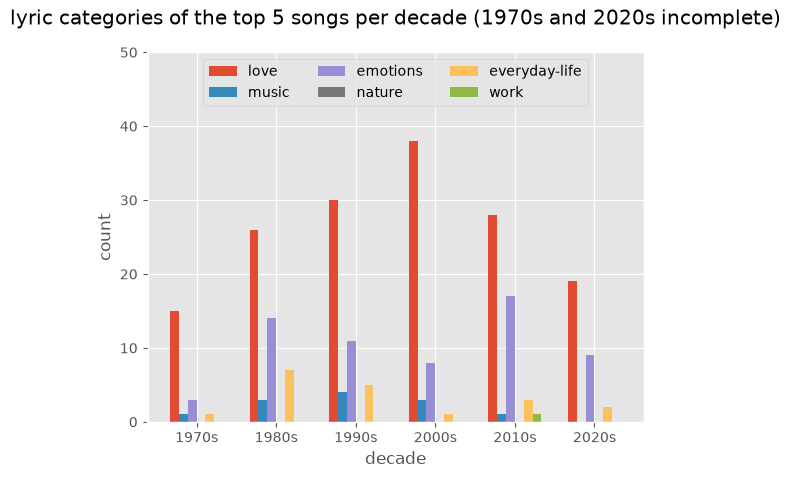

In [227]:
matplotlib.style.use('ggplot')

fig, ax = plt.subplots()
res = ax.grouped_bar(topic_dict, tick_labels=decades, group_spacing=3)

ax.set_xlabel('decade')
ax.set_ylabel('count')
ax.set_title('lyric categories of the top 5 songs per decade (1970s and 2020s incomplete)', pad=20.0)
ax.legend(loc='upper center', ncols=3)
ax.set_ylim(0, 50)

plt.show()